In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import random
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

#### Read All Data Files and Form a Single Dataset

In [2]:
transaction_0 = pd.read_csv('transactions_0.csv')
transaction_1 = pd.read_parquet('transactions_1.parquet')
transaction_2 = pd.read_json('transactions_2.json')

In [3]:
data = pd.concat([transaction_0, transaction_1, transaction_2], ignore_index=True)
data = data.set_index('Unnamed: 0')
data.index.name = None

#### Task A: Pre-Processing, Feature Selection, Sampling

##### Pre-Processing: 

Duplicated transactions, if any, are removed from the dataset. Transactions with no data in the 'is_fraud' column are removed. Other null values are handled case-by-case, based on which features will be kept in the dataset. All string values will be converted to uppercase lettering for easy comparison, and then one-hot encoded. Machine learning models such as logistic regression, support vector machines and random forest in sklearn require the data input to be numerical. All of the categorical variables need to be transformed into numerical values to be used. 

##### Feature Selection: 

- The transaction data/time field will be split into 'day_of_week' and 'hour_of_day' columns, and the original column will not be included in the dataset to prevent redundant information. The unix time feature will also not be included for redundancy
- The credit card number will not be included in the dataset as it may not contribute significantly to the classifier. It is a unique identifier of the customer, and has too many unique values across the dataset to find meaningful trends. The similar reasoning applies to the transaction number that can be removed from the dataset.
- The merchant feature will not be included in the dataset. There are too many unique values/strings present in the column that are difficult to one-hot encode due to the curse of dimenstionality.
- The first and last name of the customer will not be included in the dataset as the name of the customer does not have a correlation with fraud transactions.  
- The category feature can be one-hot encoded, after adjusting for upper/lowercase differences and included in the dataset as it has limited and manageable number of unique values. Missing values can be imputed with the modal category.
- The amount feature can be remained in the dataset as is.
- The sex feature can be included and represented by 0 and 1 for male and female. The missing values can be imputed by a random choice between male and female.
- The street address is unique to the customer and has too many unique values for meaningful patterning. City and zip code aspects of the address refer to small regions of area in the United States that do not hold enough distribution of fraud cases to make a substantial difference to the classifier. In other words, there are several unique cities and zipcodes across which the density of fraud cases is low. Hence, there three fields can be removed.
- The state column, due to its representation of a larger geographic area, it may be more helpful than using city or zipcodes. As the state column can consist of data from 50 states, one-hot encoding this may lead to the curse of dimensionality. Instead, the top 9 states will be taken into consideration, while the remaining states are substitued with 'other'. This will then be one-hot encoded to give 10 new columns instead of 50. 
- The city population feature has shown an interesting distribution of fraud cases across different city sizes. This numeric feature can be maintained as is, with the missing values imuputed with the median city size.
- The date of birth column of the customer can be converted to an age, and then discretized into categories. While the actual age may not be fruitful in the classifier, the age group of the customer can give insight into targetted populations. Missing values can imputed with the median age.
- The customer latitude/longitude and merchant latitude/longitude can be transformed into new feature of the distance between the customer's location and the merchant's location. This would provide a more meaningful metric than the individual location of the customer and merchant.
- The job feature has several unique values present. Due to the vastness of the job categories, it is quite difficult to group and categorize the data present in the column. For this reason, it can be removed from the dataset.
- The 'is_fraud' column acts as the ground truth label to be learned and predicted by the model.

##### Sampling:

The dataset is imbalanced due to the limited number of fraudulent transactions compared to the large number of legitimate transactions as found in the exploratory data analysis. Less than 1% of the dataset contains Synthetic Minority Oversampling Technique, SMOTE, is a data augmentation technique used to oversample the minority class in imbalanced datasets. SMOTE can be used on the fraudulent transactions to synthesize new examples. However, due to the overwhelming number of legitimate transactions, random undersampling of the majority class will be done first. SMOTE will be then performed on the training dataset after splitting the training and test datasets to prevent data leakage. Stratified sampling techniques when creating the training and testing datasets will allow subsets created from the dataset to have the same distribution of fraudulent and legitimate transactions as the original data. 

In [4]:
# remove duplicated transactions
data.drop_duplicates(inplace=True)

In [5]:
# find number of transactions with missing data in each column
print('Number of Transactions:')
print(len(data))

print('Number of Transactions with NA values:')
print(data.isna().any(axis=1).sum())

print('\nNumber of NA Values by Column:')
print(data.isna().sum())

Number of Transactions:
1112037
Number of Transactions with NA values:
858079

Number of NA Values by Column:
trans_date_trans_time         0
cc_num                        0
merchant                 110941
category                 110931
amt                           0
first                    111023
last                     111199
sex                      111364
street                   110765
city                     111335
state                    111181
zip                      111241
lat                           0
long                          0
city_pop                 110896
job                      111401
dob                      111330
trans_num                     0
unix_time                111474
merch_lat                     0
merch_long                    0
is_fraud                 110882
dtype: int64


As almost 77% of the transactions contain missing values, the data points cannot be simply removed from the dataset entirely. The 'is_fraud' label is required for training and testing the model as we are examining supervised learning approaches. The 110882 records without a label will be removed from the dataset. The remaining missing values can be imputed if the column is being used.

In [6]:
data = data[data['is_fraud'].notna()]
fraud = data['is_fraud'].map({1.0: 'fraudulent', 0.0: 'non-fraudulent'})
fraud = fraud.value_counts()
print(fraud)

is_fraud
non-fraudulent    995411
fraudulent          5744
Name: count, dtype: int64


In [7]:
#capitalize all strings
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].str.upper() 

In [8]:
#trans_data_trans_time column --> day_of_week and hour_of_day
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'], errors='coerce')
data = data[data['trans_date_trans_time'] <= datetime.now()]
data['day_of_week'] = data['trans_date_trans_time'].apply(lambda x: x.weekday() if not pd.isnull(x) else np.nan)
data['hour_of_day'] = data['trans_date_trans_time'].apply(lambda x: x.hour if not pd.isnull(x) else np.nan)
data['trans_date_trans_time'] = data['trans_date_trans_time'].dt.strftime('%m/%d/%Y %H:%M:%S')

#impute modal day of week and modal hour of day
data['day_of_week'].fillna(data['day_of_week'].mode()[0], inplace=True)
data['hour_of_day'].fillna(data['hour_of_day'].mode()[0], inplace=True)

In [9]:
#category column
data['category'].fillna(data['category'].mode()[0], inplace=True)


In [10]:
#sex column
data['sex'] = data['sex'].replace({'M': 0, 'F': 1})

#impute random values 0, 1 for missing values 
data['sex'].fillna(random.choice([0, 1]), inplace=True)
print(data['sex'])

0         1.0
1         1.0
2         0.0
3         0.0
4         0.0
         ... 
741353    1.0
741354    0.0
741355    1.0
741356    1.0
741357    0.0
Name: sex, Length: 667408, dtype: float64


In [11]:
# state column
top_states = data['state'].value_counts()[:9].index.tolist()
data['state'] = data['state'].apply(lambda x: x if x in top_states else 'Other')
data['state'].fillna('Other', inplace=True)

In [12]:
#city_pop column
data['city_pop'].fillna(data['city_pop'].median(), inplace=True)

In [13]:
data['dob'] = pd.to_datetime(data['dob'], format = 'mixed')
today = datetime.today()
data['age'] = data['dob'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

#creating discretized age groups
bins = [0, 18, 30, 40, 50, 60, 70, 80, 100]
labels = [0, 1, 2, 3, 4, 5, 6, 7 ]
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
data['age_group'].fillna(data['age_group'].mode()[0], inplace=True)

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

In [15]:
data['distance'] = data.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

In [16]:
print(data.dtypes)

trans_date_trans_time            object
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
sex                             float64
street                           object
city                             object
state                            object
zip                             float64
lat                             float64
long                            float64
city_pop                        float64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                        object
merch_lat                       float64
merch_long                      float64
is_fraud                        float64
day_of_week                       int64
hour_of_day                       int64
age                             float64


From the processed data, we can extract the desired features to form the dataset. 

In [17]:
dataset = data[['amt', 'day_of_week', 'hour_of_day', 'category', 'sex', 'state', 'city_pop', 'age_group', 'distance', 'is_fraud']]

In [18]:
dataset = pd.get_dummies(dataset, columns = ['category', 'state'])
dataset.replace(to_replace = True, value = 1, inplace = True)
dataset.replace(to_replace = False, value = 0, inplace = True)
dataset = dataset.apply(pd.to_numeric, errors='coerce')
dataset = dataset[[x for x in dataset if x not in 'is_fraud'] + ['is_fraud']]

In [19]:
print(dataset.dtypes)

amt                        float64
day_of_week                  int64
hour_of_day                  int64
sex                        float64
city_pop                   float64
age_group                    int64
distance                   float64
category_ENTERTAINMENT       int64
category_FOOD_DINING         int64
category_GAS_TRANSPORT       int64
category_GROCERY_NET         int64
category_GROCERY_POS         int64
category_HEALTH_FITNESS      int64
category_HOME                int64
category_KIDS_PETS           int64
category_MISC_NET            int64
category_MISC_POS            int64
category_PERSONAL_CARE       int64
category_SHOPPING_NET        int64
category_SHOPPING_POS        int64
category_TRAVEL              int64
state_AL                     int64
state_CA                     int64
state_FL                     int64
state_IL                     int64
state_MI                     int64
state_NY                     int64
state_OH                     int64
state_Other         

#### Task B: Model and Hyperparameter Selection

##### Models: 

For this task, the logistic regression, multi-layer perceptron (MLP), and random forest models will be evaluated on the dataset. The dataset is standard scaled by removing the mean and scaling to unit variance. The dataset is then split into a training set and a test set with a 80/20 split. Stratified splitting is used to ensure that there is an equal distribution of fraud transactions in the training and test sets. 

The model performance will be evaluated using the following metrics: 
- Accuracy: Provides the ratio of correctly predicted instances over the total instances.
- Precision: Indicates the ratio of correctly predicted positive observations to the total predicted positives.
- Recall: Indicates the ratio of correctly predicted positive observations to all observations in the actual class.
- F1 Score: Harmonic mean of precision and recall, useful for imbalanced classes.
- ROC AUC: Measures the area under the receiver operating characteristic curve, providing a single metric for model performance across all classification thresholds.

These metrics provide a comprehensive view of model performance, especially in the context of imbalanced datasets. While accuracy alone might be misleading, precision, recall, F1 score, and ROC AUC provide more nuanced insights into the classifier's performance.

##### Hyperparameters:
The following hyperparameters will be evaluated: 

- Logistic Regression: C (inverse of regularization strength), solver
- MLP: hidden_layer_sizes (number of neurons in hidden layers), activation (activation function), alpha (L2 penalty)
- Random Forest: n_estimators (number of trees), max_depth (maximum depth of the tree)

To test the hyperparameters, stratified 5-fold cross validation will be used. As the dataset is imbalanced, the stratification will ensure an even distribution of fraudulent cases amongst each fold. Cross-validation, with five iterations, derives a more accurate estimate of model prediction performance. 

##### Criteria for Selection:
The model with the highest ROC AUC score will be considered the best-performing model, as it balances the trade-offs between sensitivity and specificity across all classification thresholds.


In [20]:
# Sample data (replace with your dataset)
X = dataset.drop(columns=['is_fraud'])
Y = dataset['is_fraud']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split for initial train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, stratify=Y, random_state=42)


In [21]:
# Random undersample majority class - legitimate transactions
undersample = RandomUnderSampler(sampling_strategy=0.01)
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

fraud = y_train_under.map({1.0: 'fraudulent', 0.0: 'non-fraudulent'})
fraud = fraud.value_counts()
print(fraud)

is_fraud
non-fraudulent    313800
fraudulent          3138
Name: count, dtype: int64


In [22]:
# SMOTE Oversample minority class - fraudulent transactions
#smote = SMOTE(n_jobs=-1)
#X_train_smote, y_train_smote = smote.fit_resample(X_train_under, y_train_under)

#fraud = y_train_smote.map({1.0: 'fraudulent', 0.0: 'non-fraudulent'})
#fraud = fraud.value_counts()
#print(fraud)

*(Note to Professor: I intended on using SMOTE to close the gap in the imbalanced dataset. However, due to computational limitations, I was not able to run it. For the sake of completing this assignment, I'm choosing to resort to random oversampling of the fraudulent transactions. Ideally, I would have preferred SMOTE as it introduces variety into the data, as opposed to duplicating it*

In [23]:
# Random oversample minority class - fraudulent transactions
oversample = RandomOverSampler()
X_train_over, y_train_over = oversample.fit_resample(X_train_under, y_train_under)

fraud = y_train_over.map({1.0: 'fraudulent', 0.0: 'non-fraudulent'})
fraud = fraud.value_counts()
print(fraud)

is_fraud
non-fraudulent    313800
fraudulent        313800
Name: count, dtype: int64


In [24]:
# Define models and hyperparameters
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Multi-Layer Perceptron': MLPClassifier(max_iter=100)
}

params = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
    'Random Forest': {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]},
    'Multi-Layer Perceptron': {'hidden_layer_sizes': [(50,), (100,), (100, 50)], 'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001]}  
}

# Perform stratified cross-validation and hyperparameter tuning
best_models = {}
results = {}

for model_name in models:
    clf = GridSearchCV(models[model_name], params[model_name], cv=StratifiedKFold(n_splits=5), scoring='roc_auc', n_jobs = -1)
    clf.fit(X_train_over, y_train_over)
    best_models[model_name] = clf.best_estimator_
    results[model_name] = {
        'best_params': clf.best_params_,
        'best_score': clf.best_score_,
        'cv_results': clf.cv_results_
    }

Logistic Regression
Random Forest
Multi-Layer Perceptron


/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimiza

In [25]:
for model_name in models:
    print(model_name)
    print('Best Parameters: ' + str(results[model_name]['best_params']))
    print('Best Score: ' + str(results[model_name]['best_score']))
    print('\n')

Logistic Regression
Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Score: 0.884536976172748


Random Forest
Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Score: 1.0


Multi-Layer Perceptron
Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}
Best Score: 0.9996133604155724




Based on the 5-fold stratified cross-validation, the Random Forest algorithm outperformed other models with an ROC-AUC score of 1.0. The optimal parameters were determined to be with no maximum depth (max_depth=None) and 200 trees in the forest (n_estimators=200). The excellent ROC-AUC score suggests an excellent ability to distinguish between the positive and negative classes. It also suggests that this model can be trusted to perform well in real-world scenarios. Given that the model does not overfit and performs well with a moderate number of trees, it should be computationally efficient enough for real-time or near-real-time predictions in a production environment. Although the current performance is excellent, it is crucial to implement ongoing monitoring to ensure that the model continues to perform well as new data comes in. Periodic retraining and validation against new data will help maintain performance.

#### Task C: Model Performance Analysis

The optimal model and hyperparamters found through cross-validation testing was the Random Forest algorithm with no maximum depth (max_depth=None) and 200 trees in the forest (n_estimators=100). This can now be evaluated on the test set. The ROC curve and the Precision-Recall Curve can be plotted to have a visual description of the model's performance. 

In [32]:
optimal_model = RandomForestClassifier(max_depth=None, n_estimators=200)
optimal_model.fit(X_train_over, y_train_over)

y_pred_probability = optimal_model.predict_proba(X_test)[:, 1]
y_pred = optimal_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_probability)

accuracy = accuracy_score(y_test, optimal_model.predict(X_test))
precision = precision_score(y_test, optimal_model.predict(X_test))
recall = recall_score(y_test, optimal_model.predict(X_test))
f1 = f1_score(y_test, optimal_model.predict(X_test))

In [33]:
print('ROC AUC: ' + str(roc_auc))
print('Accuracy: ' + str(accuracy))
print('Precision: ' + str(precision))
print('Recall: ' + str(recall))
print('F1 Score: ' + str(f1))

ROC AUC: 0.9924113980468602
Accuracy: 0.9977899641899283
Precision: 0.8561046511627907
Recall: 0.7503184713375797
F1 Score: 0.7997284453496267


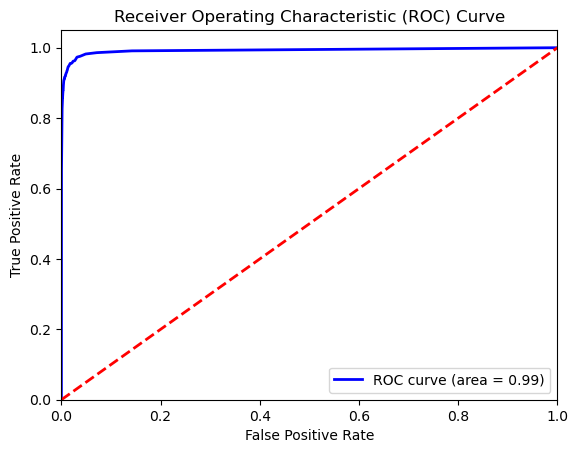

In [34]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probability)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

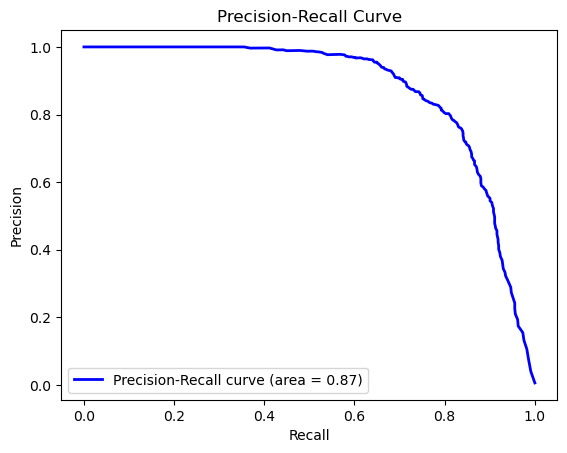

In [35]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_probability)
average_precision = average_precision_score(y_test, y_pred_probability)

# Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

An ROC-AUC score of 0.992 indicates that the Random Forest model has an excellent ability to distinguish between the positive and negative classes, which is crucial for assessing the overall performance of the classifier. The model achieves a very high accuracy of 99.8%. However, accuracy alone can be misleading, especially in the context of imbalanced datasets. The precision of 0.856 and recall of 0.750 suggest that while the model is quite good at identifying true positives, there is still room for improvement in identifying all actual positive cases. The F1 score of 0.799 provides a balanced measure of the model's precision and recall.

While the current model performs well, optimizing the decision threshold could further balance precision and recall based on specific use-case requirements. For example, if recall is more critical, the threshold could be adjusted to favor higher recall, even at the expense of precision. Implementing a system for continuous performance monitoring will ensure that the model maintains its performance over time. This includes tracking metrics like ROC-AUC, precision, recall, and F1 score on new data. Since class imbalance can significantly affect model performance, ensure that techniques like SMOTE or other oversampling/undersampling methods are part of the data preprocessing pipeline during retraining. Subgroup analysis should be performed to check for model biases and ensure fair performance across different demographic groups or other relevant subgroups. Feature importance scores from the Random Forest can be used to understand which features are most influential in making predictions. This can provide insights for further feature engineering or domain-specific adjustments. Implementing specific capability testing can ensure the model performs well under various scenarios, such as high-confidence predictions or specific edge cases.


To conduct a subgroup analysis, the category column is used to see if fraudulent charges of a certain transaction category are easier or harder to accurately identify.

In [36]:
columns = ['category_ENTERTAINMENT', 'category_FOOD_DINING', 'category_GAS_TRANSPORT', 'category_GROCERY_NET', 'category_GROCERY_POS', 'category_HEALTH_FITNESS', 'category_HOME', 'category_KIDS_PETS', 'category_MISC_NET', 'category_MISC_POS', 'category_PERSONAL_CARE', 'category_SHOPPING_NET', 'category_SHOPPING_POS', 'category_TRAVEL']

X_test_df = pd.DataFrame(X_test, columns=X.columns, index = y_test.index)
subgroup_results = []

for column in columns:
    subgroup_indices = X_test_df[column] == X_test_df[column].max()
    y_test_subgroup = y_test[subgroup_indices]
    y_pred_subgroup = y_pred[subgroup_indices]
    y_pred_proba_subgroup = y_pred_probability[subgroup_indices]
    
    if len(y_test_subgroup) > 0:
        roc_auc = roc_auc_score(y_test_subgroup, y_pred_proba_subgroup)
        accuracy = accuracy_score(y_test_subgroup, y_pred_subgroup)
        precision = precision_score(y_test_subgroup, y_pred_subgroup, zero_division=0)
        recall = recall_score(y_test_subgroup, y_pred_subgroup)
        f1 = f1_score(y_test_subgroup, y_pred_subgroup)
        
        subgroup_results.append({
            'Subgroup Value': column,
            'ROC AUC': roc_auc,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })

In [37]:
subgroup_results_df = pd.DataFrame(subgroup_results)
print(subgroup_results_df)

             Subgroup Value   ROC AUC  Accuracy  Precision    Recall  F1 Score
0    category_ENTERTAINMENT  0.999591  0.999427   0.823529  0.875000  0.848485
1      category_FOOD_DINING  0.915185  0.998459   1.000000  0.071429  0.133333
2    category_GAS_TRANSPORT  0.994021  0.996006   0.638095  0.507576  0.565401
3      category_GROCERY_NET  0.995405  0.996644   0.500000  0.214286  0.300000
4      category_GROCERY_POS  0.999999  0.999912   0.994118  1.000000  0.997050
5   category_HEALTH_FITNESS  0.945581  0.997963   0.500000  0.062500  0.111111
6             category_HOME  0.998529  0.998951   0.714286  0.555556  0.625000
7        category_KIDS_PETS  0.959166  0.997781   0.300000  0.157895  0.206897
8         category_MISC_NET  0.999555  0.996650   0.902439  0.860465  0.880952
9         category_MISC_POS  0.968519  0.997945   0.875000  0.333333  0.482759
10   category_PERSONAL_CARE  0.944386  0.997959   0.000000  0.000000  0.000000
11    category_SHOPPING_NET  0.999882  0.997733   0.

Categories such as category_ENTERTAINMENT, category_GROCERY_POS, and category_SHOPPING_NET have very high ROC AUC scores and balanced precision and recall values, indicating excellent model performance in these areas. Categories like category_FOOD_DINING, category_PERSONAL_CARE, and category_TRAVEL show significantly lower performance, with some metrics (like precision and recall) being zero. This indicates that the model struggles to correctly predict the positive class for these subgroups. There is considerable variability in precision and recall across different subgroups. For instance, category_GAS_TRANSPORT has decent precision but lower recall, indicating that while the model correctly identifies positive cases, it misses a fair number of them.

The subgroup analysis reveals significant variability in model performance across different categories, indicating potential biases and areas of unfairness. To address this, the system design should incorporate targeted improvements for poorly performing subgroups, such as gathering more training data and engineering specific features. Implementing continuous monitoring and alert systems to track subgroup performance will ensure prompt identification and resolution of issues. Data augmentation techniques can enhance the training set for underperforming subgroups. Regular re-training and validation with balanced data distribution will maintain model performance over time, resulting in a robust, fair, and reliable system that promotes equity across all data segments.